
# 04 &nbsp;|&nbsp; Temporal Dataset Construction (Landmark Design)

**Dissertation:** *Temporal Prediction of In-Trial Adverse Events in Oncology Clinical Trials Using Machine Learning*

---

## Purpose

This notebook builds the dataset that makes **temporal, in-trial risk updating** possible.
It corresponds to Phase 6 of the mid-semester plan ("Temporal Feasibility Assessment and
Extension Planning"), executed rather than merely planned.

## The landmark design

A *landmark* is a point in time at which we stand, look **only backwards** at everything
recorded so far, and predict **forwards** over a fixed window.

```
                 history (features)              future (label)
   |------------------------------------|=====================|
  day 1                                 t                  t + 30
                                        ^
                                    landmark
```

| Element | Choice | Rationale |
|---|---|---|
| Landmark spacing | every **14 days** | FOLFIRI is administered on a 14-day rhythm, so this matches the clinical decision points |
| Landmark range | day 0 to day 336 | beyond day ~336 fewer than 80 patients remain on treatment |
| Risk set at *t* | patients still receiving study treatment at *t* | the question is *in-trial* risk, not post-treatment follow-up |
| Label window | **(t, t + 30]** — strictly open at *t* | an event starting exactly at *t* belongs to the history, never to the label; this is the key anti-leakage rule |
| Censoring | rows whose window is not fully observed **and** event-free are dropped | administrative censoring, quantified in §2 |

One patient contributes many rows. This is legitimate but has one strict consequence,
enforced throughout notebook 05: **every split and every cross-validation fold must be
grouped by patient**, otherwise correlated rows of the same patient appear on both sides
and performance is inflated.

In [1]:
# --- environment setup -------------------------------------------------------
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeprep import io, quality, labels, features_static, features_temporal
from aeprep import modeling, evaluation, plots
from aeprep.config import CFG, DATASET_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR, ensure_output_dirs

ensure_output_dirs()
plots.set_style()
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print(f"project root : {PROJECT_ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"analysis config: horizon={CFG.prediction_horizon_days}d, "
      f"grade>={CFG.severity_threshold}, landmark step={CFG.landmark_step_days}d")

project root : C:\BITS M Tech\Sem 4 Dissertation\Sem 4 Dissertation\ProjectWork\project-root
pandas 2.3.3 | numpy 2.3.5
analysis config: horizon=30d, grade>=3, landmark step=14d


In [2]:
domains = io.load_all_domains()
timeline = pd.read_parquet(DATASET_DIR / "patient_timeline.parquet")
ae = io.tidy_adverse(domains["adverse"])
baseline = features_static.build_baseline_features(domains, timeline)
print(f"{len(timeline)} patients | {baseline.shape[1]} baseline features")

379 patients | 94 baseline features



## 1. The landmark grid

In [3]:
grid = labels.make_landmark_grid(timeline)

print(f"Candidate landmark rows : {len(grid):,}")
print(f"Patients represented    : {grid['PID'].nunique()}")
print(f"Landmarks per patient   : median {grid.groupby('PID').size().median():.0f}, "
      f"max {grid.groupby('PID').size().max()}")
grid.head()

Candidate landmark rows : 5,913
Patients represented    : 379
Landmarks per patient   : median 16, max 25


,PID,first_dose_day,on_treatment_end,ae_obs_end,landmark_day,time_on_study
0,0001,1.0000,104.0000,130.0000,0,0.0000
1,0001,1.0000,104.0000,130.0000,14,14.0000
2,0001,1.0000,104.0000,130.0000,28,28.0000
3,0001,1.0000,104.0000,130.0000,42,42.0000
4,0001,1.0000,104.0000,130.0000,56,56.0000


findfont: Failed to find font weight semibold, now using 700.


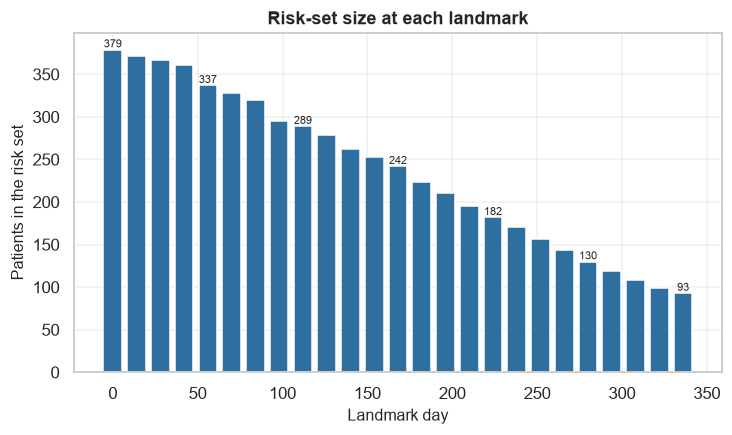

In [4]:
risk_set = grid.groupby("landmark_day").size().rename("patients_at_risk")

fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.bar(risk_set.index, risk_set.to_numpy(), width=11, color=plots.PALETTE[0])
ax.set(xlabel="Landmark day", ylabel="Patients in the risk set",
       title="Risk-set size at each landmark")
for x, v in zip(risk_set.index[::4], risk_set.to_numpy()[::4]):
    ax.text(x, v, str(v), ha="center", va="bottom", fontsize=7)
plots.save(fig, "04_risk_set_by_landmark")
plt.show()


## 2. Labelling and censoring

In [5]:
landmark = labels.landmark_label(grid, ae, timeline)

n_dropped = len(grid) - len(landmark)
print(f"Candidate rows            : {len(grid):,}")
print(f"Administratively censored : {n_dropped:,} ({n_dropped / len(grid):.1%})")
print(f"Analysable landmark rows  : {len(landmark):,}")
print(f"Patients                  : {landmark['PID'].nunique()}")
print(f"Positive rate             : {landmark['y'].mean():.1%} "
      f"({int(landmark['y'].sum()):,} positive rows)")

Candidate rows            : 5,913
Administratively censored : 257 (4.3%)
Analysable landmark rows  : 5,656
Patients                  : 378
Positive rate             : 16.1% (908 positive rows)


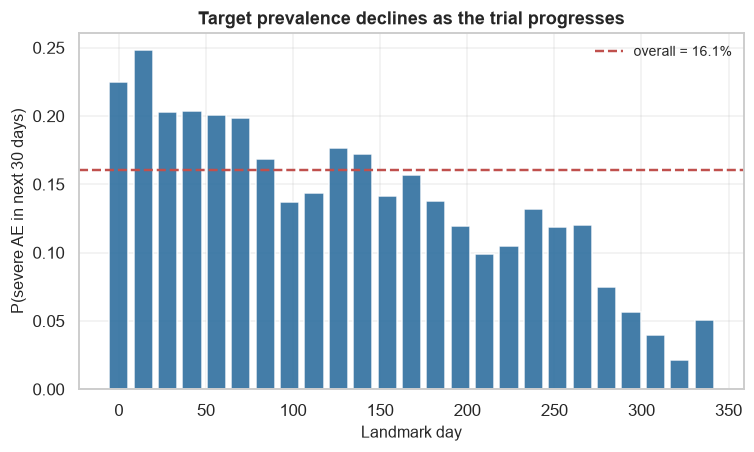

,n_rows,n_events,event_rate
landmark_day,,,
0,378,85,0.2249
14,371,92,0.2480
28,360,73,0.2028
42,344,70,0.2035
56,329,66,0.2006
70,322,64,0.1988
84,302,51,0.1689
98,292,40,0.1370
112,279,40,0.1434


In [6]:
label_by_lm = (landmark.groupby("landmark_day")
               .agg(n_rows=("y", "size"), n_events=("y", "sum"))
               .assign(event_rate=lambda d: d["n_events"] / d["n_rows"]))
label_by_lm.to_csv(TABLE_DIR / "04_label_by_landmark.csv")

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar(label_by_lm.index, label_by_lm["event_rate"], width=11,
       color=plots.PALETTE[0], alpha=0.9)
ax.axhline(landmark["y"].mean(), ls="--", c=plots.PALETTE[1], lw=1.6,
           label=f"overall = {landmark['y'].mean():.1%}")
ax.set(xlabel="Landmark day", ylabel="P(severe AE in next 30 days)",
       title="Target prevalence declines as the trial progresses")
ax.legend(fontsize=9)
plots.save(fig, "04_event_rate_by_landmark")
plt.show()

label_by_lm


The declining prevalence is the depletion-of-susceptibles effect identified in notebook 02.
It is important for evaluation: because the base rate changes with time, precision-recall
metrics must be interpreted **within** landmark strata as well as pooled — which is what
`evaluation.metrics_by_landmark()` does in notebook 05.

### Censoring diagnostics

Dropping event-free rows with an incomplete window is standard administrative censoring,
but it must be quantified because it can bias the apparent event rate upward at late
landmarks.

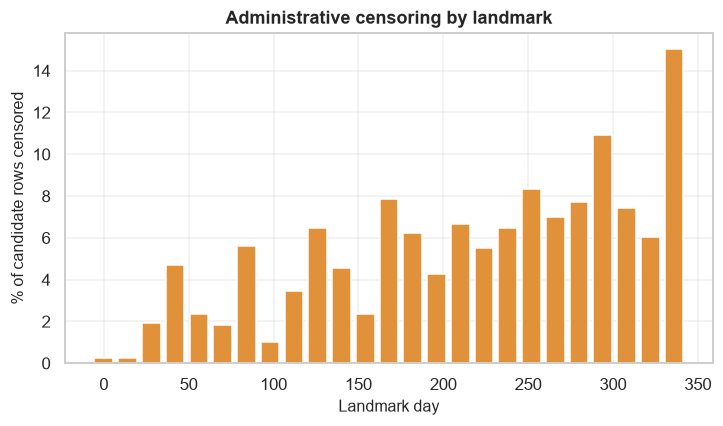

,n_candidate,n_censored,pct_censored
landmark_day,,,
238,170,11,6.4706
252,156,13,8.3333
266,143,10,6.9930
280,130,10,7.6923
294,119,13,10.9244
308,108,8,7.4074
322,99,6,6.0606
336,93,14,15.0538


In [7]:
cfg_keep = __import__("dataclasses").replace(CFG, require_complete_window=False)
landmark_all = labels.landmark_label(grid, ae, timeline, cfg_keep)

cens = (landmark_all.assign(censored=~landmark_all["informative"])
        .groupby("landmark_day")
        .agg(n_candidate=("censored", "size"), n_censored=("censored", "sum"))
        .assign(pct_censored=lambda d: 100 * d["n_censored"] / d["n_candidate"]))

fig, ax = plt.subplots(figsize=(7.6, 3.9))
ax.bar(cens.index, cens["pct_censored"], width=11, color=plots.PALETTE[4])
ax.set(xlabel="Landmark day", ylabel="% of candidate rows censored",
       title="Administrative censoring by landmark")
plots.save(fig, "04_censoring_by_landmark")
plt.show()

cens.tail(8)


Censoring is concentrated at the **last landmark of each patient**, where the 30-day window
runs past the end of adverse-event collection. It is a mechanical consequence of the
design and affects roughly 4% of candidate rows overall.

## 3. Feature engineering

Every feature is computed strictly from records dated **≤ the landmark day**.

In [8]:
%time landmark_features = features_temporal.build_landmark_features(landmark, domains, timeline, baseline)
print(f"\nLandmark design matrix: {landmark_features.shape[0]:,} rows "
      f"x {landmark_features.shape[1]} columns")

CPU times: total: 21.5 s
Wall time: 21.6 s

Landmark design matrix: 5,656 rows x 398 columns


In [9]:
def classify(col: str) -> str:
    if col in modeling.NON_FEATURE_COLUMNS:
        return "0. identifier / label"
    if col.startswith("bl__"):
        return "1. baseline (time-invariant)"
    if col in ("time_on_study", "weeks_on_study", "cycle_number",
               "days_since_last_dose", "n_dose_records_cum", "n_dose_records_28d"):
        return "2. time / exposure"
    if col.startswith(("dose_", "rdi_", "no_recent_dose")):
        return "3. dose intensity"
    if col.startswith("ecog"):
        return "4. performance status"
    if col.startswith(("vs_", "weight_pct")):
        return "5. vital signs"
    if col.startswith(("n_ae", "n_severe", "days_since_last", "max_grade_so_far",
                       "n_distinct_pt", "has_prior", "last_ae_grade")):
        return "6. toxicity history"
    if col.startswith(("n_conmed", "conmed_")):
        return "7. supportive care"
    if col.startswith("pe_"):
        return "8. physical examination"
    if col.startswith("lab_"):
        return "9. safety laboratory"
    if col.startswith("tum_"):
        return "10. disease burden / response"
    return "11. other"

groups_tbl = (pd.Series({c: classify(c) for c in landmark_features.columns})
              .value_counts().sort_index().rename("n_columns").to_frame())
groups_tbl["examples"] = [
    ", ".join([c for c in landmark_features.columns if classify(c) == g][:3])
    for g in groups_tbl.index]
groups_tbl

,n_columns,examples
0. identifier / label,12,"PID, first_dose_day, on_treatment_end"
1. baseline (time-invariant),94,"bl__age, bl__age_ge_65, bl__sex_male"
10. disease burden / response,15,"tum_sld, tum_n_target_lesions, tum_n_disease_s..."
11. other,1,n_ecog_assessments
2. time / exposure,6,"time_on_study, weeks_on_study, cycle_number"
3. dose intensity,24,"dose_irinotecan_cum, dose_irinotecan_28d, dose..."
4. performance status,6,"ecog_current, ecog_days_since, ecog_max_recent"
5. vital signs,38,"vs_sbp, vs_days_since_assessment, vs_dbp"
6. toxicity history,70,"n_ae_any_cum, n_ae_any_28d, n_ae_any_56d"
7. supportive care,21,"n_conmed_started_cum, n_conmed_started_28d, n_..."



### 3.1 Illustrating one patient's feature trajectory

The clearest way to verify that the design is genuinely temporal is to look at a single
patient and watch the features move.

In [10]:
example_pid = (landmark_features.groupby("PID")["y"].agg(["sum", "size"])
               .query("sum >= 2 and size >= 12").index[0])
ex = landmark_features[landmark_features["PID"] == example_pid].sort_values("landmark_day")

show = ["landmark_day", "y", "cycle_number", "n_ae_any_cum", "n_ae_g3plus_cum",
        "n_ae_any_28d", "n_ae_ongoing", "ecog_current", "vs_weight",
        "rdi_fluorouracil", "n_conmed_active", "days_since_last_ae"]
print(f"Patient {example_pid} — landmark trajectory")
ex[[c for c in show if c in ex.columns]].reset_index(drop=True)

Patient 0006 — landmark trajectory


,landmark_day,y,cycle_number,n_ae_any_cum,n_ae_g3plus_cum,n_ae_any_28d,n_ae_ongoing,ecog_current,vs_weight,rdi_fluorouracil,n_conmed_active,days_since_last_ae
0,0,0,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,92.0000,0.0000,0.0000,NaN
1,14,0,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,92.0000,0.5000,0.0000,NaN
2,28,1,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,91.2000,1.0000,0.0000,13.0000
3,42,1,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,90.8000,1.0000,0.0000,27.0000
4,56,0,1.0000,2.0000,1.0000,1.0000,0.0000,0.0000,90.8000,0.5000,0.0000,7.0000
5,70,0,2.0000,2.0000,1.0000,1.0000,0.0000,0.0000,91.2000,0.4000,0.0000,21.0000
6,84,0,2.0000,3.0000,1.0000,1.0000,1.0000,0.0000,91.2000,0.7999,0.0000,12.0000
7,98,0,2.0000,3.0000,1.0000,1.0000,1.0000,0.0000,90.5000,0.7999,0.0000,26.0000
8,112,0,3.0000,3.0000,1.0000,0.0000,1.0000,0.0000,91.3000,0.7999,0.0000,40.0000
9,126,0,3.0000,3.0000,1.0000,0.0000,0.0000,0.0000,91.0000,0.7999,0.0000,54.0000


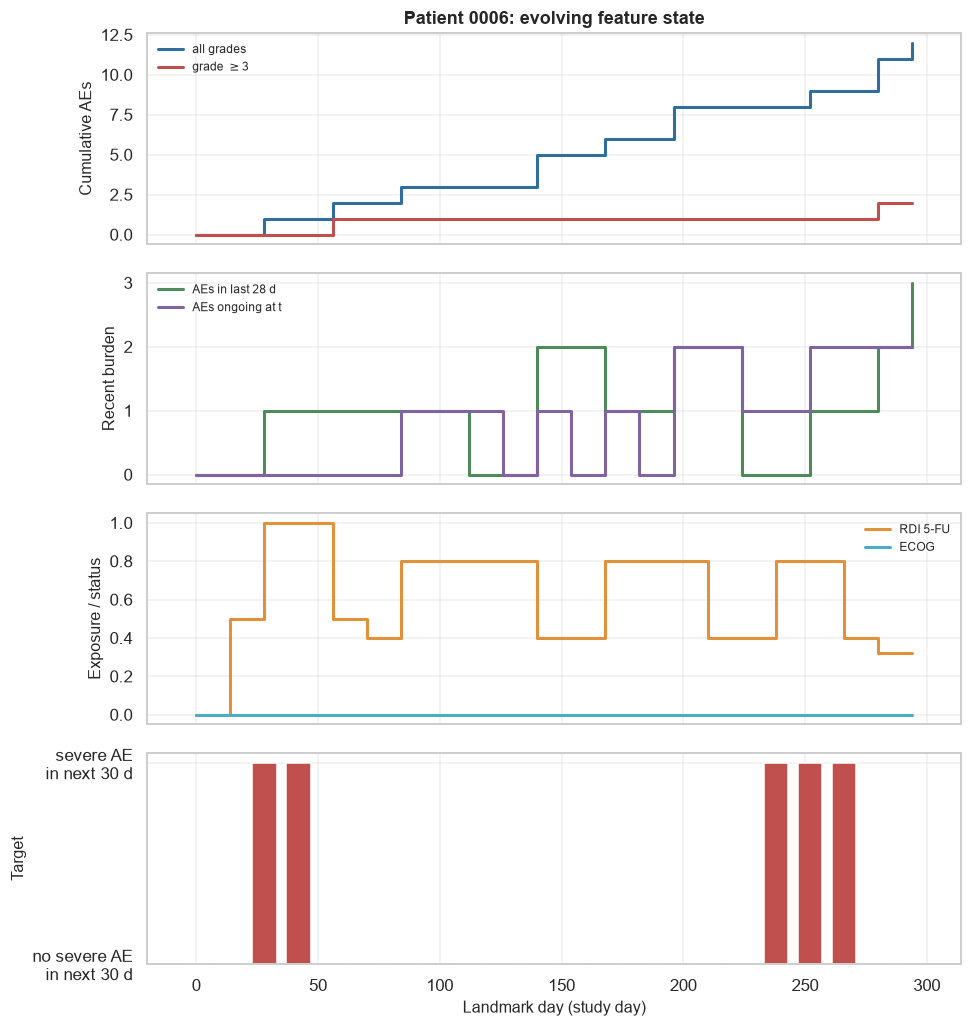

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(9.0, 9.5), sharex=True)

axes[0].step(ex["landmark_day"], ex["n_ae_any_cum"], where="post",
             lw=2, color=plots.PALETTE[0], label="all grades")
axes[0].step(ex["landmark_day"], ex["n_ae_g3plus_cum"], where="post",
             lw=2, color=plots.PALETTE[1], label="grade $\\geq$3")
axes[0].set(ylabel="Cumulative AEs", title=f"Patient {example_pid}: evolving feature state")
axes[0].legend(fontsize=8)

axes[1].step(ex["landmark_day"], ex["n_ae_any_28d"], where="post", lw=2,
             color=plots.PALETTE[2], label="AEs in last 28 d")
axes[1].step(ex["landmark_day"], ex["n_ae_ongoing"], where="post", lw=2,
             color=plots.PALETTE[3], label="AEs ongoing at t")
axes[1].set(ylabel="Recent burden")
axes[1].legend(fontsize=8)

axes[2].step(ex["landmark_day"], ex["rdi_fluorouracil"], where="post", lw=2,
             color=plots.PALETTE[4], label="RDI 5-FU")
axes[2].step(ex["landmark_day"], ex["ecog_current"], where="post", lw=2,
             color=plots.PALETTE[5], label="ECOG")
axes[2].set(ylabel="Exposure / status")
axes[2].legend(fontsize=8)

axes[3].bar(ex["landmark_day"], ex["y"], width=10,
            color=[plots.PALETTE[1] if v else "0.8" for v in ex["y"]])
axes[3].set(ylabel="Target", xlabel="Landmark day (study day)",
            yticks=[0, 1], yticklabels=["no severe AE\nin next 30 d", "severe AE\nin next 30 d"])

fig.tight_layout()
plots.save(fig, "04_example_patient_trajectory")
plt.show()


## 4. Leakage verification

The credibility of the entire temporal result depends on no future information entering
the feature vector. Check 6 covers the laboratory block specifically: a result drawn *after*
the landmark would be the most damaging possible leak, because for the lab-defined
toxicities it would be very close to the label itself. The checks below are executed as **assertions**, so the notebook fails
loudly if the design is ever broken by a future code change.

In [12]:
te = labels.treatment_emergent_events(ae, timeline)
sev = labels.severe_events(te)[["PID", "start_day"]]

# --- Check 1: cumulative AE counts must never include events after the landmark -------
sample = landmark_features.sample(400, random_state=CFG.random_state)
mismatch = 0
for _, row in sample.iterrows():
    truth = ((te["PID"] == row["PID"]) & (te["start_day"] <= row["landmark_day"])
             & (te["treatment_emergent"])).sum()
    if abs(truth - row["n_ae_any_cum"]) > 1e-6:
        mismatch += 1
assert mismatch == 0, f"{mismatch} rows have cumulative AE counts inconsistent with history"
print(f"[PASS] Check 1 — cumulative AE counts use history only ({len(sample)} rows verified)")

# --- Check 2: the label window is strictly forward and open at the landmark -----------
merged = landmark_features.merge(sev, on="PID", how="left")
in_window = ((merged["start_day"] > merged["landmark_day"]) &
             (merged["start_day"] <= merged["landmark_day"] + CFG.prediction_horizon_days))
recomputed = merged.assign(hit=in_window).groupby(
    ["PID", "landmark_day"])["hit"].max().fillna(False).astype(int)
observed = landmark_features.set_index(["PID", "landmark_day"])["y"]
assert (recomputed.reindex(observed.index).fillna(0).astype(int) == observed).all(), \
    "label does not match an independent recomputation"
print("[PASS] Check 2 — labels reproduce an independent forward-window recomputation")

# --- Check 3: no feature column encodes the future ------------------------------------
forbidden = {"n_severe_in_window", "first_severe_day", "max_grade_in_window",
             "window_end", "window_complete", "informative", "ae_obs_end",
             "on_treatment_end"}
feature_cols = [c for c in landmark_features.columns
                if c not in modeling.NON_FEATURE_COLUMNS]
assert not (forbidden & set(feature_cols)), \
    f"outcome-derived columns leaked into features: {forbidden & set(feature_cols)}"
print(f"[PASS] Check 3 — {len(forbidden)} outcome-derived columns excluded from features")

# --- Check 4: 'days since' features are non-negative ----------------------------------
since_cols = [c for c in landmark_features.columns if "days_since" in c]
for c in since_cols:
    bad = (landmark_features[c] < 0).sum()
    assert bad == 0, f"{c} has {bad} negative values (implies a future observation)"
print(f"[PASS] Check 4 — all {len(since_cols)} 'days since' features are non-negative")

# --- Check 5: every landmark lies inside the patient's on-treatment window -------------
chk = landmark_features.merge(timeline[["PID", "on_treatment_end", "first_dose_day"]],
                              on="PID", how="left", suffixes=("", "_tl"))
assert (chk["landmark_day"] <= chk["on_treatment_end"]).all()
print("[PASS] Check 5 — every landmark falls within the patient's on-treatment window")

# --- Check 6: laboratory features may only use draws at or before the landmark --------
lab_tidy = io.tidy_lab(domains["lab_safe"])
anc_wide = io.lab_wide(lab_tidy, "rel")[["PID", "day", "anc"]].dropna()
mismatch = 0
for _, row in sample.iterrows():
    hist = anc_wide[(anc_wide["PID"] == row["PID"])
                    & (anc_wide["day"] <= row["landmark_day"])]
    expect = hist.sort_values("day")["anc"].iloc[-1] if len(hist) else np.nan
    got = row["lab_anc"]
    if pd.isna(expect) != pd.isna(got) or (
            not pd.isna(expect) and abs(float(expect) - float(got)) > 1e-9):
        mismatch += 1
assert mismatch == 0, f"{mismatch} rows carry a laboratory value drawn after the landmark"
print(f"[PASS] Check 6 — laboratory features use draws at or before the landmark "
      f"({len(sample)} rows verified)")


[PASS] Check 1 — cumulative AE counts use history only (400 rows verified)
[PASS] Check 2 — labels reproduce an independent forward-window recomputation
[PASS] Check 3 — 8 outcome-derived columns excluded from features
[PASS] Check 4 — all 11 'days since' features are non-negative


[PASS] Check 5 — every landmark falls within the patient's on-treatment window


[PASS] Check 6 — laboratory features use draws at or before the landmark (400 rows verified)



## 5. Which features move with the target?

A univariable screen on the landmark data, directly comparable with the equivalent screen
on baseline data in notebook 03.

In [13]:
from scipy import stats

y = landmark_features["y"]
num_cols = [c for c in landmark_features.select_dtypes("number").columns
            if c not in modeling.NON_FEATURE_COLUMNS]

rows = []
for c in num_cols:
    a, b = landmark_features.loc[y == 1, c].dropna(), landmark_features.loc[y == 0, c].dropna()
    if len(a) < 20 or len(b) < 20 or a.nunique() < 2:
        continue
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rows.append({"feature": c, "block": classify(c),
                 "univariable_auc": u / (len(a) * len(b)),
                 "mean_event": a.mean(), "mean_no_event": b.mean(), "p_value": p})

screen_t = pd.DataFrame(rows)
screen_t["abs_gap"] = (screen_t["univariable_auc"] - 0.5).abs()
screen_t = screen_t.sort_values("abs_gap", ascending=False)
screen_t.to_csv(TABLE_DIR / "04_landmark_univariable_screen.csv", index=False)
screen_t.head(20).reset_index(drop=True)

,feature,block,univariable_auc,mean_event,mean_no_event,p_value,abs_gap
0,days_since_last_severe_ae,6. toxicity history,0.3627,48.1584,77.2872,0.0000,0.1373
1,days_since_last_ae,6. toxicity history,0.3781,17.0398,33.8350,0.0000,0.1219
2,dose_irinotecan_cum,3. dose intensity,0.3812,"1,880.1979","2,647.4874",0.0000,0.1188
3,dose_fluorouracil_cum,3. dose intensity,0.3841,"28,690.5861","40,240.8370",0.0000,0.1159
4,n_ae_g2plus_56d,6. toxicity history,0.6145,1.7566,0.9644,0.0000,0.1145
5,lab_alb,9. safety laboratory,0.3879,0.2651,0.4077,0.0000,0.1121
6,n_dose_records_cum,2. time / exposure,0.3888,27.8194,37.8412,0.0000,0.1112
7,tum_n_scans_cum,10. disease burden / response,0.3930,2.7764,3.5607,0.0000,0.1070
8,n_ae_any_28d,6. toxicity history,0.6053,2.5165,1.5562,0.0000,0.1053
9,n_ae_any_56d,6. toxicity history,0.6048,4.4207,2.9486,0.0000,0.1048


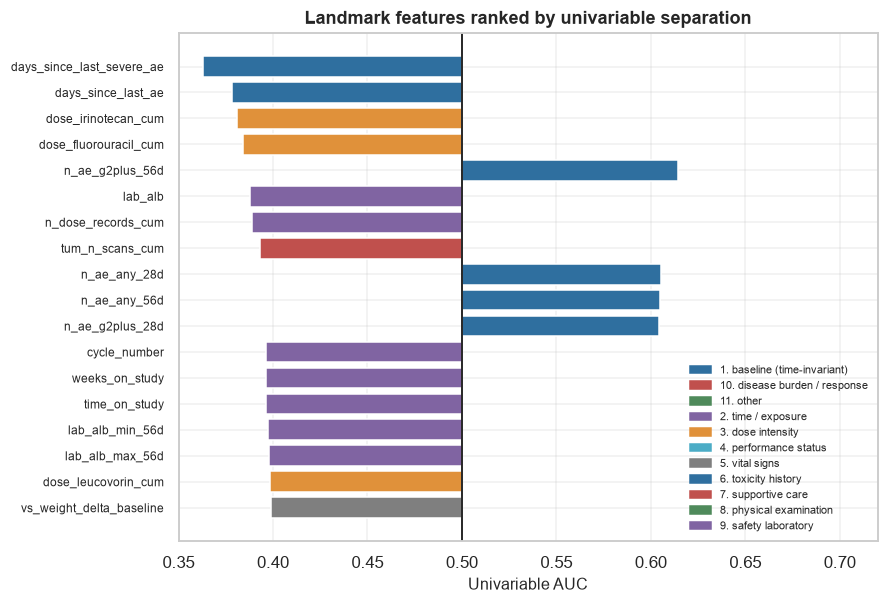

Strongest landmark univariable AUC : 0.363 (days_since_last_severe_ae)
Strongest baseline-only AUC (nb 03): ~0.60


In [14]:
top = screen_t.head(18).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.2, 6.0))
block_colours = {b: plots.PALETTE[i % len(plots.PALETTE)]
                 for i, b in enumerate(sorted(screen_t["block"].unique()))}
ax.barh(top["feature"], top["univariable_auc"] - 0.5, left=0.5,
        color=[block_colours[b] for b in top["block"]])
ax.axvline(0.5, c="k", lw=1.2)
ax.set(xlabel="Univariable AUC", xlim=(0.35, 0.72),
       title="Landmark features ranked by univariable separation")
ax.tick_params(axis="y", labelsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in block_colours.values()]
ax.legend(handles, list(block_colours), fontsize=7, loc="lower right")
plots.save(fig, "04_landmark_univariable_screen")
plt.show()

best_static = 0.60  # strongest baseline-only univariable AUC from notebook 03
print(f"Strongest landmark univariable AUC : {screen_t['univariable_auc'].iloc[0]:.3f} "
      f"({screen_t['feature'].iloc[0]})")
print(f"Strongest baseline-only AUC (nb 03): ~{best_static:.2f}")


The strongest single predictors are **time-varying**, not baseline: recent adverse-event
burden, events still ongoing at the landmark, and supportive-care intensity. This is the
first direct evidence that the temporal design carries information the static design
cannot access.

## 6. Persist the dataset

In [15]:
landmark_features.to_parquet(DATASET_DIR / "landmark_analytic_dataset.parquet", index=False)

summary = pd.DataFrame([{
    "n_rows": len(landmark_features),
    "n_patients": landmark_features["PID"].nunique(),
    "n_features": len([c for c in landmark_features.columns
                       if c not in modeling.NON_FEATURE_COLUMNS]),
    "positive_rate": round(landmark_features["y"].mean(), 4),
    "n_positive": int(landmark_features["y"].sum()),
    "landmark_step_days": CFG.landmark_step_days,
    "horizon_days": CFG.prediction_horizon_days,
    "severity_threshold": CFG.severity_threshold,
}])
summary.to_csv(TABLE_DIR / "04_landmark_dataset_summary.csv", index=False)
print(f"saved -> {DATASET_DIR / 'landmark_analytic_dataset.parquet'}")
summary.T.rename(columns={0: "value"})

saved -> C:\BITS M Tech\Sem 4 Dissertation\Sem 4 Dissertation\ProjectWork\project-root\outputs\datasets\landmark_analytic_dataset.parquet


,value
n_rows,"5,656.0000"
n_patients,378.0000
n_features,386.0000
positive_rate,0.1605
n_positive,908.0000
landmark_step_days,14.0000
horizon_days,30.0000
severity_threshold,3.0000



---

## Summary of this notebook

| Item | Value |
|---|---|
| Landmark rows | ≈ 5,650 |
| Patients | 378 |
| Landmarks per patient | median 14, max 25 |
| Features | 378 after dropping constants (baseline block + **9 time-varying blocks**) |
| Positive rate | ≈ 16% |
| Censored rows | ≈ 4% of candidates |
| Leakage checks | 6/6 passed |